In [1]:
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold
from torch.utils.data.dataloader import DataLoader
from torch.utils.data.dataset import TensorDataset

plt.style.use("default")

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False) # X: (70000, 784)

In [4]:
X, y = mnist["data"], mnist["target"]
X = torch.Tensor(X.astype(np.float32) / 255.0)
y = torch.Tensor(y.astype(np.int64))
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)
X_test = X_test.to(device)

In [5]:
X_trainval.shape

torch.Size([60000, 784])

In [23]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_train_data_loaders = []
k_test_data_loaders = []

for train_idx, test_idx in skf.split(X_trainval, y_trainval):
    train_dataset = TensorDataset(X_trainval[train_idx].to(device), y_trainval[train_idx].to(device))
    test_dataset = TensorDataset(X_trainval[test_idx].to(device), y_trainval[test_idx].to(device))

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1000)

    k_train_data_loaders.append(train_loader)
    k_test_data_loaders.append(test_loader)

In [7]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        self.input = nn.Linear(784, 2*784)
        self.hidden1 = nn.Linear(2*784, 2*784)
        self.hidden2 = nn.Linear(2*784, 2*784)
        self.output = nn.Linear(2*784, 10)
        self.relu = nn.ReLU()
        self.softmax = nn.LogSoftmax(dim=1)

        self.train_loss_per_epoch = None
        self.test_loss_per_epoch = None

    def forward(self, x):
        x = self.relu(self.input(x))
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        x = self.output(x)
        x = self.softmax(x)
        return x

In [26]:
def train_one_model(fold: int, max_epochs: int, train_loader: DataLoader, test_loader: DataLoader) -> MLP:
    model = MLP()
    model.to(device)
    model.train()

    loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

    n_reports = 10
    print_every = max(max_epochs // n_reports, 1)

    train_loss_per_epoch = np.zeros(max_epochs)
    test_loss_per_epoch = np.zeros(max_epochs)

    for epoch in range(max_epochs):
        for data, target in train_loader:
            optimizer.zero_grad()

            y_pred = model(data)

            loss = loss_fn(y_pred, target.long())
            loss.backward()

            optimizer.step()

        model.eval()

        with torch.no_grad():
            loss = 0.0

            for data, target in train_loader:
                y_pred = model(data)
                loss += loss_fn(y_pred, target.long()).item()

            loss_avg = loss / len(train_loader)
            train_loss_per_epoch[epoch] = loss_avg

            loss = 0.0

            for data, target in test_loader:
                y_pred = model(data)
                loss += loss_fn(y_pred, target.long()).item()

            loss_avg = loss / len(test_loader)
            test_loss_per_epoch[epoch] = loss_avg

            if epoch % print_every == 0:
                print(f"{fold=} {epoch=}\tCrossEntropy = {loss_avg:.3f}")

        model.train()

    model.train_loss_per_epoch = train_loss_per_epoch
    model.test_loss_per_epoch = test_loss_per_epoch

    model.eval()
    return model

In [9]:
def train_models_5fold(max_epochs: int) -> list[MLP]:
    models = []

    for fold, (train_loader, test_loader) in enumerate(zip(k_train_data_loaders, k_test_data_loaders)):
        model = train_one_model(fold, max_epochs, train_loader, test_loader)
        models.append(model)

    return models

In [14]:
model_sgd = train_one_model(0, 1, k_train_data_loaders[0], k_test_data_loaders[0])

fold=0 epoch=0	CrossEntropy = 0.363


Final accuracy = 0.900


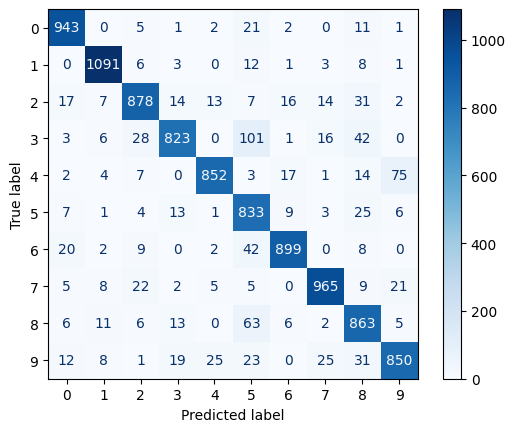

In [15]:
with torch.no_grad():
    y_pred = model_sgd(X_test)
    y_pred = np.argmax(y_pred.detach().cpu(), axis=1)
    accuracy = accuracy_score(y_pred, y_test)
    print(f"Final accuracy = {accuracy:.3f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [21]:
def evaluate_k_models(models: list[MLP]):
    fig, axs = plt.subplots(len(models), 2, figsize=(4*2, 4*len(models)))

    for fold, model in enumerate(models):
        ax = axs[fold, 0]
        ax.plot(np.arange(len(model.train_loss_per_epoch)), model.train_loss_per_epoch, label="train loss")
        ax.plot(np.arange(len(model.test_loss_per_epoch)), model.test_loss_per_epoch, label="test loss")
        ax.legend()
        ax.set_title(f"{fold=}")

        ax = axs[fold, 1]
        with torch.no_grad():
            y_pred = model(X_test)
            y_pred = np.argmax(y_pred.detach().cpu(), axis=1)
            accuracy = accuracy_score(y_pred, y_test)

        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues", ax=ax)
        ax.set_title(f"{accuracy=}")

    plt.show()

In [28]:
models = train_models_5fold(10)

fold=0 epoch=0	CrossEntropy = 0.307
fold=0 epoch=1	CrossEntropy = 0.210
fold=0 epoch=2	CrossEntropy = 0.160
fold=0 epoch=3	CrossEntropy = 0.141
fold=0 epoch=4	CrossEntropy = 0.110
fold=0 epoch=5	CrossEntropy = 0.098
fold=0 epoch=6	CrossEntropy = 0.099
fold=0 epoch=7	CrossEntropy = 0.088
fold=0 epoch=8	CrossEntropy = 0.092
fold=0 epoch=9	CrossEntropy = 0.101
fold=1 epoch=0	CrossEntropy = 0.316
fold=1 epoch=1	CrossEntropy = 0.198
fold=1 epoch=2	CrossEntropy = 0.146
fold=1 epoch=3	CrossEntropy = 0.125
fold=1 epoch=4	CrossEntropy = 0.115
fold=1 epoch=5	CrossEntropy = 0.087
fold=1 epoch=6	CrossEntropy = 0.085
fold=1 epoch=7	CrossEntropy = 0.077
fold=1 epoch=8	CrossEntropy = 0.078
fold=1 epoch=9	CrossEntropy = 0.072
fold=2 epoch=0	CrossEntropy = 0.327
fold=2 epoch=1	CrossEntropy = 0.212
fold=2 epoch=2	CrossEntropy = 0.163
fold=2 epoch=3	CrossEntropy = 0.132
fold=2 epoch=4	CrossEntropy = 0.113
fold=2 epoch=5	CrossEntropy = 0.111
fold=2 epoch=6	CrossEntropy = 0.097
fold=2 epoch=7	CrossEntropy 

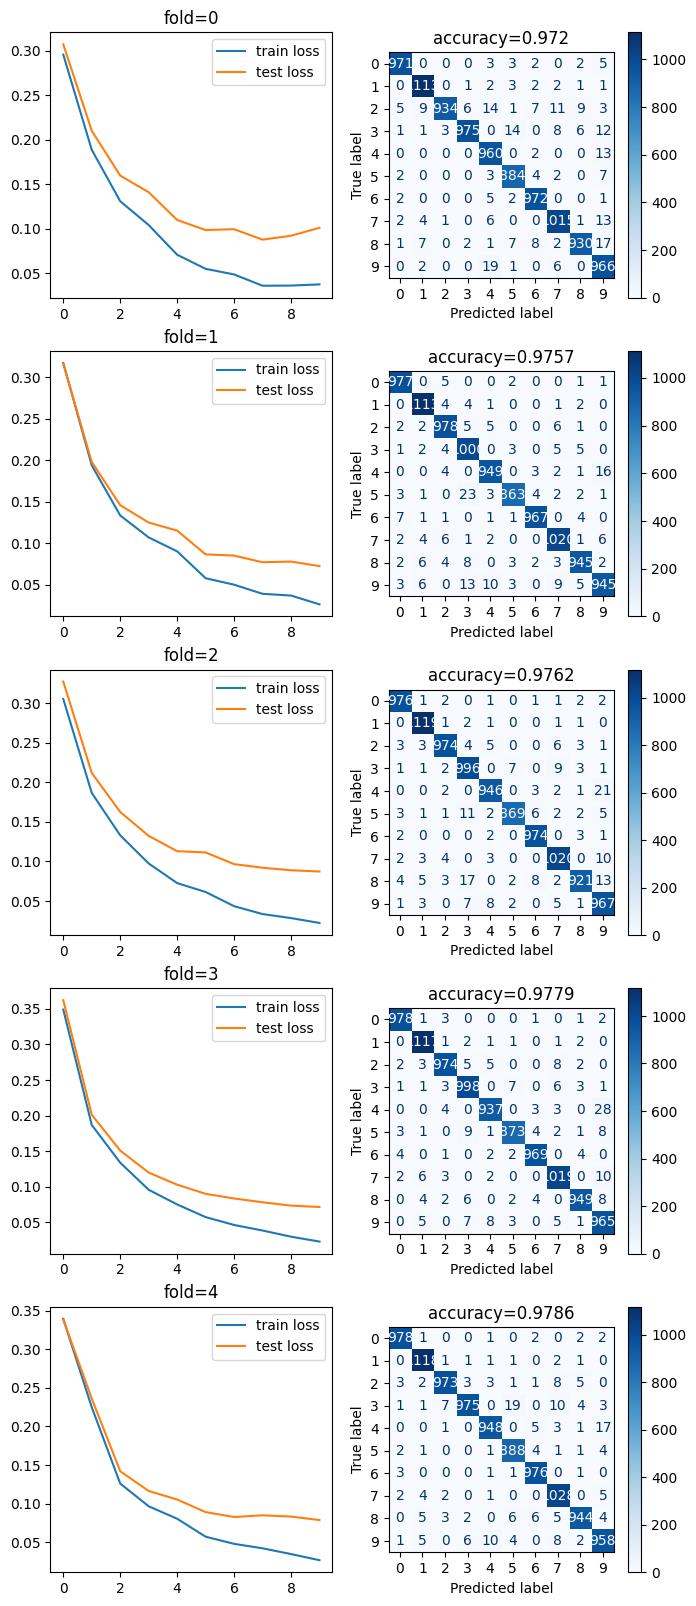

In [29]:
evaluate_k_models(models)